# Compulsory Assignment 3: Semantic Segmentation With U-net



## Assignment Submission
To complete this assignment answer the questions in this notebook and write the code required to implement the relevant models.
However, we reccomend that you start early. This assignment has subsections, each of which build upon the last. This assignment is completed by doing the following.

- Submit notebook as an .ipynb file to canvas.
- Submit notebook as an .pdf file to canvas.

Your submission must correctly implement the full pipeline to segment the images using a U-Net.
High accuracy is not required, as the purpose of this assignment is to evaluate the correct implementation of the U-Net architecture and workflow.

#### NOTE: It is recommended to use Google Colab with GPU enabled for CA3 taska. Keras and TensorFlow (version ≥2) will automatically use the GPU if one is available

- Read tasks thoroughly before answering.
- Make sure to answer all tasks.
- Ensure all code cells are run.
- Ensure all figures are visible in the PDF.
- Provide a brief explanation of how your code works




# How to Use Google Colab for CA3

To work on the CA3 assignment in Google Colab, follow these steps:

---

### 1. Connect Google Colab to Google Drive
Your CA3 files should be stored in Google Drive so Colab can access them.  
Run the following code to mount your Drive:



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



After running this, you will be asked to grant access. Once mounted, your Drive will be available under `/content/drive/MyDrive/`.

---

### 2. Upload the CA3 Folder
- First, unzip the **CA3** folder on your local computer.  
- Then upload the unzipped CA3 folder into your Google Drive (for example inside `MyDrive`).  

Example path:
/content/drive/MyDrive/CA3

### Change Runtime to GPU

To use GPU in Google Colab:

1. Go to the top menu and click **Runtime** → **Change runtime type**.  
2. In the pop-up window, set **Hardware accelerator** to **GPU**.  
3. Click **Save**.  

Now your notebook will run on a GPU backend.

---

### 3. Add CA3 to Python’s Search Path
To make sure Python finds the `utilities.py` and other scripts in CA3, add the path (the path is just an example):

import sys

sys.path.append("/content/drive/MyDrive/CA3")


Adjust the path above to match the actual location of your CA3 folder in Google Drive.

---

### 4. Open the CA3 Notebook
- Upload the CA3 Jupyter notebook (for example, `CA3.ipynb`) to Colab.  
- Once opened, you can run the notebook and it will access the files in your CA3 folder.

---

### 5. Watch the First Lecture
The first lecture explains how to use Google Colab effectively.  
Review it if you are new to Colab.

---

That’s it — you are now ready to run your CA3 code on Google Colab.


## Introduction
Chest X-ray(CXR) images are important in medical imaging because it helps focus analysis on the lung region, making disease detection (eg: pneumonia, COVID-19) more accurate and reliable. The purpose is to create clear lung masks that isolate the lungs from surrounding anatomy.

Lung segmentation is the process of separating lung regions from the rest of a chest X-ray. In this assignment, you are provided with CXR images and corresponding binary masks, where pixel values of 0 represent non-lung areas and 1 represents lung tissue. Your task is to focuse on semantic segmentation using a U-Net–style architecture. You will segment lung regions from chest X-ray images.




## Dataset

The dataset consists of 200 images with corresponding binary masks:

- **Images:** 200 chest X-ray images (grayscale).  
- **Masks:** 200 binary masks.  
  - `1` = lung  
  - `0` = background



**Structure**
- Images: `CXR_png/`  
- Masks: `masks/`  

> Mask filenames may use suffixes `_mask`.

**Pairing rule:** For `X.png`, expect `X_mask.png` (accepted suffixes).  
You must programmatically verify pairs and report any missing masks.

![image.png](attachment:612bbb55-f062-4410-b6de-88c2db964fce.png)


## Assignment Tasks

1. Build a file-pairing script to match each image with its mask; print a summary of matched pairs and missing files.  
2. Create train/val/test splits (80/10/10) with a fixed random seed.  
3. Implement preprocessing and mask-safe augmentations (flips, crop/zoom; nearest-neighbor resize for masks).  
4. Implement the classical U-Net structure that you have learned about in the lectures.  
5. Implement a U-Net with Transfer Learning (e.g., ResNet50, VGG16, MobileNetV2).  
6. Train your models with a composite loss (e.g., 0.5·BCE + 0.5·DiceLoss), track Dice and IoU metrics, and use callbacks (ModelCheckpoint, EarlyStopping).  
7. Evaluate on the test set; report metrics and show qualitative results.  


## Task 0.1 : Data Organization & Pairing
- Build a file-pairing script to match each image with its mask.  
- Print a summary of matched pairs and missing files.
- Show the distribution of training, validation and test set
##  Set DATA_ROOT to the path of the Images folder located in your CA3 assignment folder.

In [ ]:
import sys, importlib

CA3_DIR = "/content/drive/MyDrive/CA3/CA3"
if CA3_DIR not in sys.path:
  sys.path.insert(0,CA3_DIR)

import utilities as ut
importlib.reload(ut)


<module 'utilities' from '/content/drive/MyDrive/CA3/CA3/utilities.py'>

Total images: 200
Matched pairs: 200
Missing masks: 0


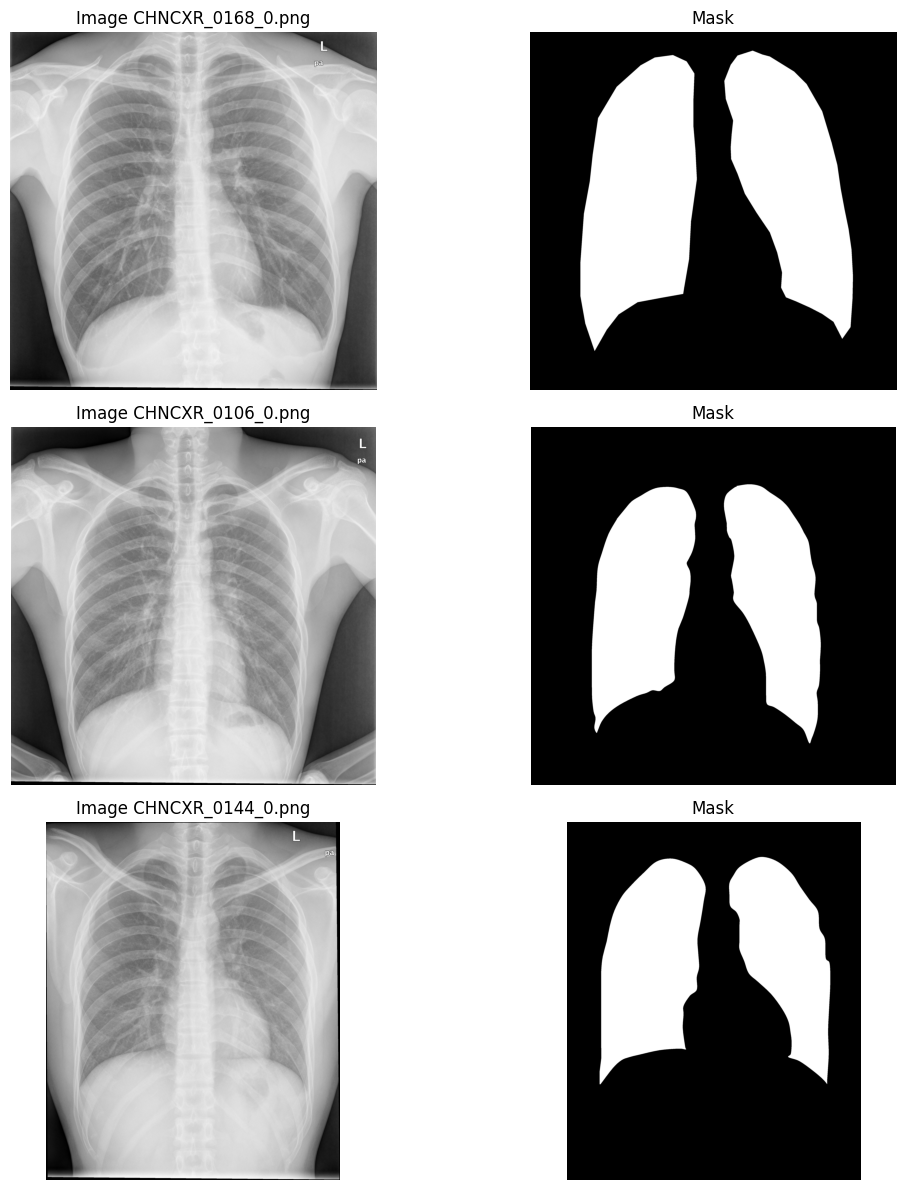

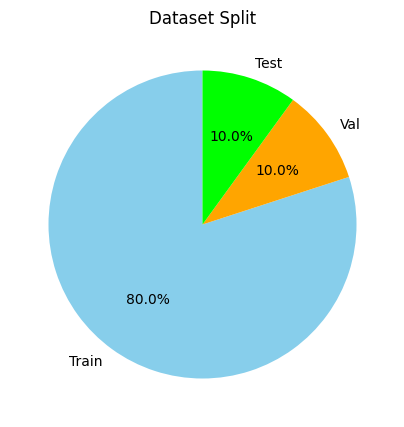

In [ ]:
import os, glob, random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
import tensorflow as tf
import sys

DATA_ROOT = r"/content/drive/MyDrive/CA3/CA3/Images"
IMG_DIR = os.path.join(DATA_ROOT, "CXR_png")
MSK_DIR = os.path.join(DATA_ROOT, "masks")

pairs, missing = ut.build_pairs(IMG_DIR, MSK_DIR)
ut.report_pairs(pairs, missing)
ut.peek_pairs(pairs, n_show=3)

train, val, test = ut.split_dataset(pairs, seed=42)
ut.plot_split_distribution(train, val, test)



## Task 0.1 : Preprocessing & Augmentation
- Implement preprocessing for images and masks.  
- Ensure masks are not corrupted during transformations.


### Image
- Decode as RGB (3 channels), resize to `IMG_SIZE`.
- Use ResNet preprocess.

### Mask
- Decode as 1 channel, nearest resize (to preserve labels).
- Binarize.

### Augmentations (mask-safe)
- Horizontal flip
- Light zoom/shift via pad + random crop
- Light brightness/contrast jitter (image only)




In [ ]:
import importlib
import utilities as ut
importlib.reload(ut)

# Build datasets
train_ds = ut.make_dataset(train, augment_data=False)   # no augmentation
val_ds   = ut.make_dataset(val, augment_data=False)
train_aug_ds = ut.make_dataset(train, augment_data=True)

# -------------------------
# Check dataset sizes
# -------------------------
print("Pairs available:")
print("  Train set:", len(train), "pairs")
print("  Val set  :", len(val), "pairs")
print("  Test set :", len(test), "pairs")

# Count actual batches and images
def count_batches_and_images(ds, name):
    n_batches = 0
    n_images = 0
    for imgs, msks in ds:
        n_batches += 1
        n_images += imgs.shape[0]
    print(f"{name}: {n_batches} batches, {n_images} images")

count_batches_and_images(train_ds, "Train dataset (no aug)")
count_batches_and_images(val_ds, "Validation dataset")
count_batches_and_images(train_aug_ds, "Train dataset (with aug)")

# -------------------------
# Inspect shapes before augmentation
# -------------------------
for imgs, msks in train_ds.take(1):
    print("Before augmentation - images:", imgs.shape, "masks:", msks.shape)

# Inspect shapes after augmentation
for imgs, msks in train_aug_ds.take(1):
    print("After augmentation - images:", imgs.shape, "masks:", msks.shape)


Pairs available:
  Train set: 160 pairs
  Val set  : 20 pairs
  Test set : 20 pairs
Train dataset (no aug): 40 batches, 160 images
Validation dataset: 5 batches, 20 images
Train dataset (with aug): 40 batches, 160 images
Before augmentation - images: (4, 512, 512, 3) masks: (4, 512, 512, 1)
After augmentation - images: (4, 512, 512, 3) masks: (4, 512, 512, 1)


## Part 1 - Model Implementation

## Intersection over Union

The IoU score is a popular metric in both segmentation and object detection problems.

If you want to use the `plot_training_history` function in the `utilities.py` library remember to compile the model with the TP, TN, FP, FN metrics such that you can estimate the *Intersection-over-Union*.  
However, it is voluntary to estimate IoU.(check the `utilities.py`)

See example below:


In [ ]:
from tensorflow.keras.metrics import FalseNegatives, FalsePositives, TrueNegatives, TruePositives
from utilities import f1_score, plot_training_history

# Example model compile
model.compile(
    optimizer="Something",
    loss="Something else",
    metrics=[
        FalseNegatives(),
        FalsePositives(),
        TrueNegatives(),
        TruePositives(),
        f1_score,
        # Other metrics of your choice
    ]
)

training_history = model.fit(X_train, y_train, ...)
plot_training_history(training_history)


NameError: name 'model' is not defined

You have also been provided with a custom F1-score metric in the `utilities.py` library, which is specific for image segmentation.  
**This is mandatory to use when compiling the model.**


## Task 1.1: Model Implementation
Implement the classical U-net structure that you have learned about in the lectures.  
Feel free to experiment with the number of layers, loss-function, batch-normalization, etc.  

**Remember to compile with the F1-score metric.**


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.metrics import TruePositives, TrueNegatives, FalsePositives, FalseNegatives
from tensorflow.keras.optimizers import Adam
import utilities as ut

#definerer et konvolusjonsblokk som brukes flere steder i u-net
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

#lager oppsamlingsblokk med skip-connection for å kombinere lav og høynivå funksjoner
def up_block(x, skip, filters):
    x = layers.Conv2DTranspose(filters, 2, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x

#bygger selve u-net modellen med encoder, bottleneck og decoder for segmentering
def build_unet(input_shape):
    inputs = layers.Input(shape=input_shape)

    c1 = conv_block(inputs, 32);  p1 = layers.MaxPooling2D()(c1)
    c2 = conv_block(p1,     64);  p2 = layers.MaxPooling2D()(c2)
    c3 = conv_block(p2,    128);  p3 = layers.MaxPooling2D()(c3)
    c4 = conv_block(p3,    256);  p4 = layers.MaxPooling2D()(c4)

    bn = conv_block(p4, 512)

    u1 = up_block(bn, c4, 256)
    u2 = up_block(u1, c3, 128)
    u3 = up_block(u2, c2,  64)
    u4 = up_block(u3, c1,  32)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(u4)
    return models.Model(inputs, outputs, name="UNet_baseline")

input_shape = (ut.IMG_SIZE[0], ut.IMG_SIZE[1], 3)
model = build_unet(input_shape)

#kompilerer modellen med adam optimalisering, tapsfunksjon og nødvendige metrikker
model.compile(
    optimizer=Adam(1e-4),
    loss=ut.bce_dice_loss,  # 0.5*BCE + 0.5*Dice
    metrics=[
        TruePositives(name="true_positives"),
        TrueNegatives(name="true_negatives"),
        FalsePositives(name="false_positives"),
        FalseNegatives(name="false_negatives"),
        ut.f1_score,
    ],
)

model.summary()


Model: "UNet_baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512, 512,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 512, 512,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │      9,248 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 512, 512,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │     36,928 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_4[0][0]  

 Total params: 7,771,873 (29.65 MB)

 Trainable params: 7,765,985 (29.62 MB)

 Non-trainable params: 5,888 (23.00 KB)

## Task 1.2: Train the model, and plot the training history
Feel free to use the `plot_training_history` function from the provided library `utilities.py`.


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - f1_score: 0.9571 - false_negatives: 329150.2812 - false_positives: 110433.5000 - loss: 0.0707 - true_negatives: 15871074.0000 - true_positives: 5185149.0000
Epoch 1: val_f1_score improved from -inf to 0.95675, saving model to /content/drive/MyDrive/CA3/CA3/unet_baseline_best.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 41s 399ms/step - f1_score: 0.9571 - false_negatives: 335797.9375 - false_positives: 113205.2891 - loss: 0.0707 - true_negatives: 16243824.0000 - true_positives: 5301692.5000 - val_f1_score: 0.9568 - val_false_negatives: 55776.0000 - val_false_positives: 42684.0000 - val_loss: 0.0736 - val_true_negatives: 4073651.0000 - val_true_positives: 1070769.0000 - learning_rate: 7.8125e-07
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - f1_score: 0.9591 - false_negatives: 320275.0938 - false_positives: 112953.5234 - loss: 0.0684 - true_negatives: 15967463.0000 - true_positives: 5095116.5000
Epoch 2: val_f1_score did not improve from 0

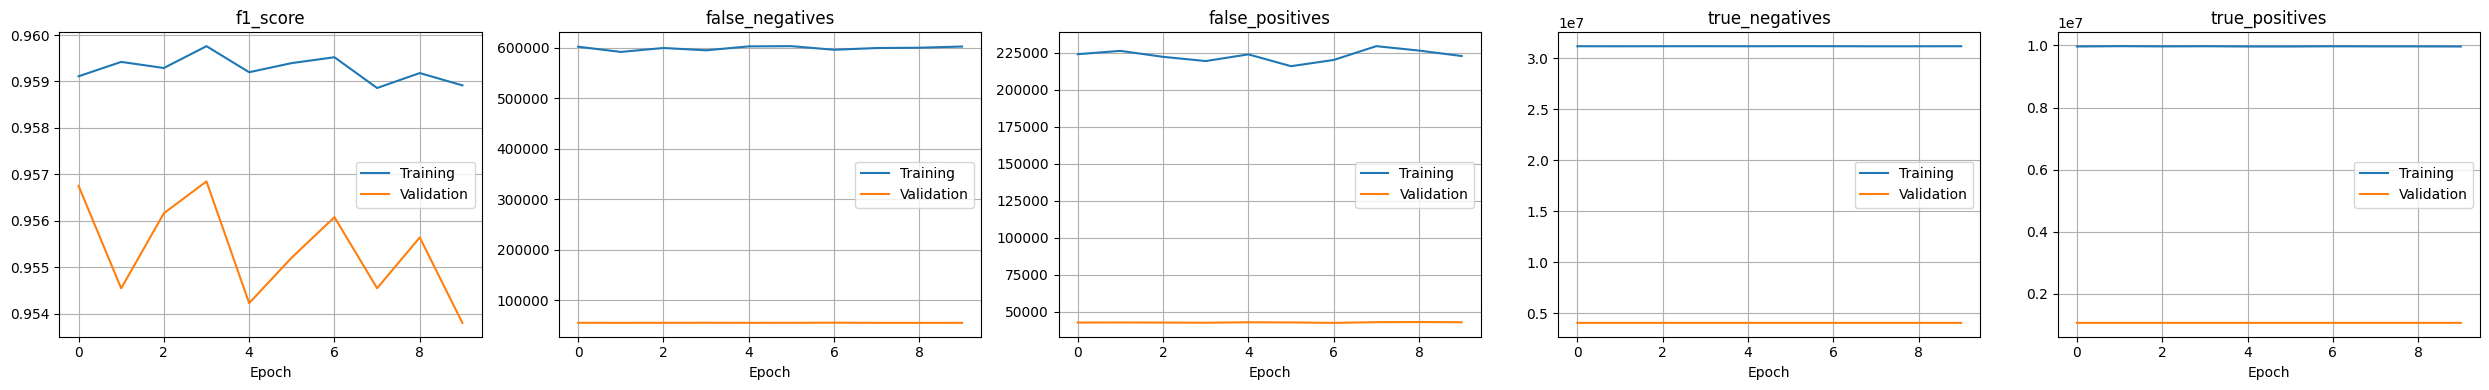

KeyError: 'F1_score'

In [ ]:
#koden funker, men på slutten får vi error,
#men alt som vi har bedt den om å gjøre har den gjort. alle epochs blir kjørt og trent og alle tabellene kommer opp

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

#bruker datasets fra task 0.1
#oppretter testdatasettet uten augmentering for evaluering etter trening
test_ds = ut.make_dataset(test, augment_data=False)

ckpt_path = "/content/drive/MyDrive/CA3/CA3/unet_baseline_best.keras"
callbacks = [
    ModelCheckpoint(ckpt_path, monitor="val_f1_score", mode="max",
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_f1_score", mode="max", patience=8,
                  restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
]

#justert epochs ned til 10 for at den skal kjøre, men kan endres (colab sine servere er ikke alltid stabile)
EPOCHS = 10
history = model.fit(
    train_aug_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

#enkel historikkplot
ut.plot_training_history(
    history,
    list_of_metrics=[
        "f1_score",
        "false_negatives",
        "false_positives",
        "true_negatives",
        "true_positives",
    ]
)


#får ut beregnet Acc/IoU/F1 fra TP/TN/FP/FN
_ = ut.plot_training_history_and_return(history)


## Task 1.3: Visualize model predictions
Make a plot that illustrates the original image, the predicted mask, and the ground truth mask. You can use visualize_predictions() in `utilities.py`

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


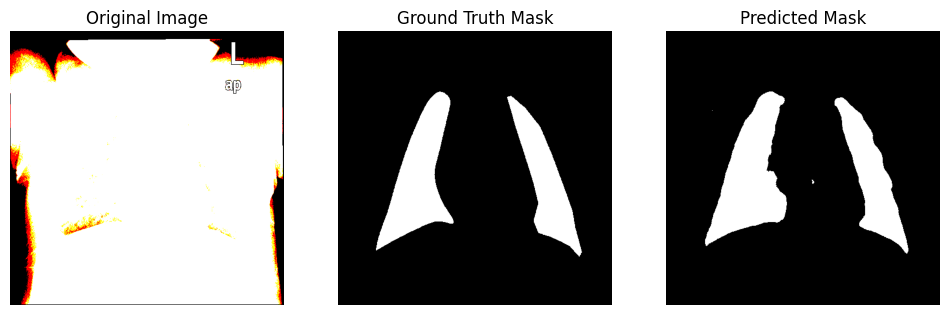

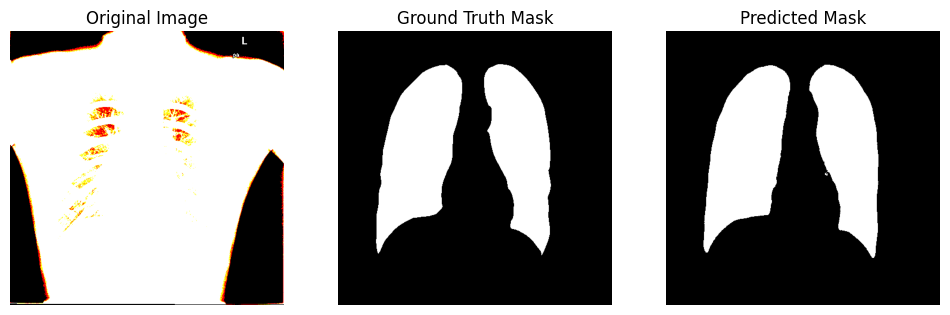

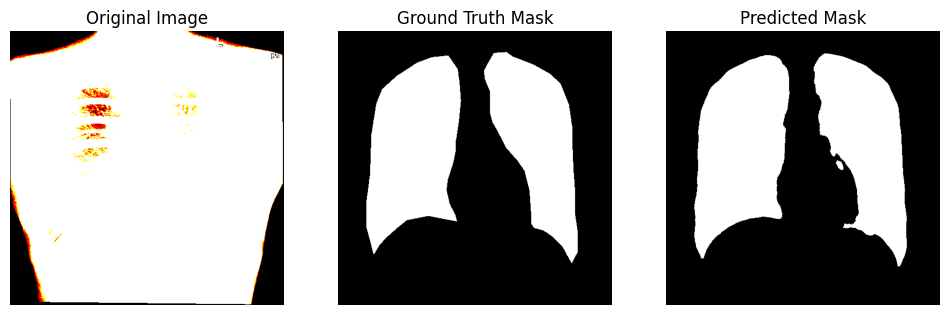

In [ ]:
#fra val eller testsettet, n kan endres til hvor mange bilder man vil se
ut.visualize_predictions(model, val_ds, n=3)

## Task 2: Implementing U-Net with Transfer Learning

Implement a model with the U-net structure that you have learned about in the lectures, but now with a pre-trained backbone.
There are many pre-trained back-bones to choose from. Pick freely from the selection here tf.keras.applications, or here Keras model scores (nicer table in the second link).
Feel free to experiment with the number of layers, loss-function, batch-normalization, etc. Many of the backbones available are quite big, so you might find it quite time-consuming to train them on your personal computers.

For those with a dedicated graphics card (NVIDIA and AMD) Tensorflow or PyTorch (not syllabus)

And wants to experiment with their own compute resources (can be a lot of fun)

Tensorflow: https://learn.microsoft.com/en-us/windows/ai/directml/gpu-tensorflow-plugin

PyTorch: https://learn.microsoft.com/en-us/windows/ai/directml/pytorch-windows



## Task 2.1: Transfer Learning Model Implementation

In this task, we will implement a U-Net model that uses the pre-trained weights of popular public networks (e.g., **VGG16** and **ResNet50**) as encoders. This is a common transfer learning strategy for segmentation.

### Example 1: U-Net with VGG16 backbone

from tensorflow.keras.applications import VGG16

from tensorflow.keras.applications import ResNet50

In [ ]:
#SE PART 2 QUESTION 3
#valgt å bruke ResNet50 som pre-trent encoder
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import TruePositives, TrueNegatives, FalsePositives, FalseNegatives
import utilities as ut

def build_unet_resnet50(input_shape=(512, 512, 3)):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False

    #henter ut feature maps som skal brukes som skip connections
    skips = [
        base_model.get_layer("conv1_relu").output,          #256 x 256
        base_model.get_layer("conv2_block3_out").output,    #128 x 128
        base_model.get_layer("conv3_block4_out").output,    #64 x  64
        base_model.get_layer("conv4_block6_out").output     #32 x  32
    ]

    #encoder-output 16x16
    encoder_output = base_model.get_layer("conv5_block3_out").output

    #decoder-del, trinnvis oppsampling og concat med skip-lagene
    x = encoder_output
    for i, skip in enumerate(reversed(skips)):
        filters = 256 // (2**i)
        x = layers.Conv2DTranspose(filters, 2, strides=2, padding="same")(x)
        x = layers.Concatenate()([x, skip])
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)

    #her er x nå 256x256, men vi trenger en oppsampling til 512x512
    x = layers.Conv2DTranspose(32, 2, strides=2, padding="same")(x)  # 256 -> 512
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    #siste lag, 1-kanals maske og sigmoid (binær segmentering)
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(x)

    model = models.Model(inputs=base_model.input, outputs=outputs, name="UNet_ResNet50")
    return model

#bygger modellen med samme img size som i utilities
input_shape = (ut.IMG_SIZE[0], ut.IMG_SIZE[1], 3)
model_tl = build_unet_resnet50(input_shape)
model_tl.summary()

#kompilerer modellen med bce+dice-tap og F1 + TP/TN/FP/FN-metrier
model_tl.compile(
    optimizer=Adam(1e-4),
    loss=ut.bce_dice_loss,
    metrics=[
        TruePositives(name="true_positives"),
        TrueNegatives(name="true_negatives"),
        FalsePositives(name="false_positives"),
        FalseNegatives(name="false_negatives"),
        ut.f1_score
    ]
)


Model: "UNet_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 518, 518,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 256, 256,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 256, 256,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 256, 256,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 258, 258,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 128, 128,  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 128, 128,  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 128, 128,  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 128, 128,  │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 128, 128,  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 128, 128,  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 128, 128,  │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 128, 128,  │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 128, 128,  │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 128, 128,  │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 128, 128,  │      1,024 │ conv2_block1_3_c

 Total params: 30,557,441 (116.57 MB)

 Trainable params: 6,967,745 (26.58 MB)

 Non-trainable params: 23,589,696 (89.99 MB)

##  Task 2.2: Train the transfer learning model and plot the training history

Feel free to use the plot_training_history function from the provided library utilities.py


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - f1_score: 0.5278 - false_negatives: 1113147.5000 - false_positives: 5227288.5000 - loss: 0.6080 - true_negatives: 10758637.0000 - true_positives: 4396735.0000
Epoch 1: val_f1_score improved from -inf to 0.08544, saving model to /content/drive/MyDrive/CA3/CA3/unet_resnet50_best.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 94s 592ms/step - f1_score: 0.5313 - false_negatives: 1120703.3750 - false_positives: 5294333.0000 - loss: 0.6050 - true_negatives: 11067009.0000 - true_positives: 4512476.0000 - val_f1_score: 0.0854 - val_false_negatives: 1076260.0000 - val_false_positives: 10852.0000 - val_loss: 0.5783 - val_true_negatives: 4105483.0000 - val_true_positives: 50285.0000 - learning_rate: 1.0000e-04
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - f1_score: 0.9115 - false_negatives: 220311.5312 - false_positives: 642715.5000 - loss: 0.2310 - true_negatives: 15442467.0000 - true_positives: 5190314.0000
Epoch 2: val_f1_score improved from 0.08

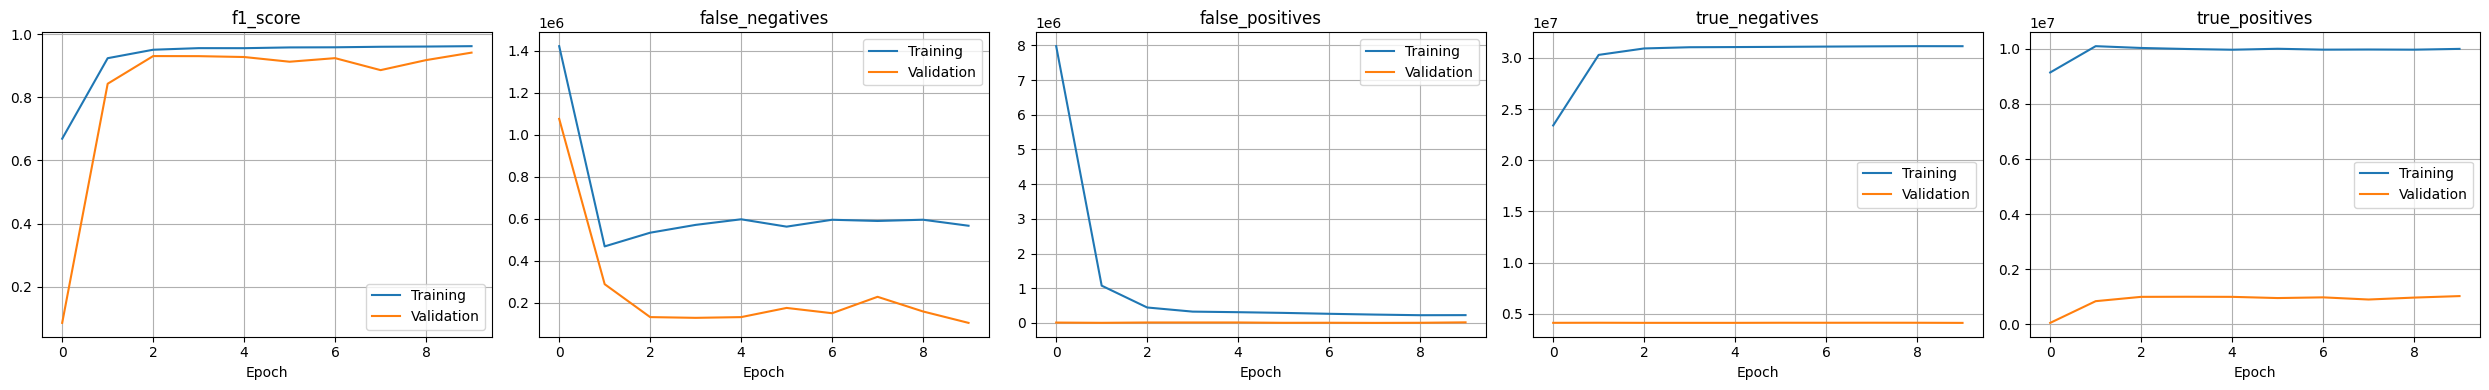

In [ ]:
#SE PART 2 QUESTION 3
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

#definerer lagringssti og callbacks for ytelse og forbedre treningsprosessen
ckpt_path = "/content/drive/MyDrive/CA3/CA3/unet_resnet50_best.keras"
callbacks = [
    ModelCheckpoint(ckpt_path, monitor="val_f1_score", mode="max",
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_f1_score", mode="max", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
]

EPOCHS = 10  #vi valgte 10, kan endres
history_tl = model_tl.fit(
    train_aug_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

#enkel plot history
ut.plot_training_history(
    history_tl,
    list_of_metrics=["f1_score", "false_negatives", "false_positives", "true_negatives", "true_positives"]
)

# Part 2 - Discussion

#### Question 1: Which model architectures did you explore, and what type of hyperparameter optimization did you try?
Answer 1:  Vi utforsket to U-Net-arkitekturer for semantisk segmentering av lungeområder: en grunnleggende u-net bygget fra bunnen av, og en u-net med resnet50 som forhåndstrent encoder. Den første modellen brukte standard konvolusjon og oppsamlingsblokker, mens resnet50 modellen brukte forhåndstrente vekter fra imagenet for å trekke ut mer avanserte bildeegenskaper. Vi eksperimenterte med læringsrater (1e-3 til 1e-4), bruk av batch normalisering og en sammensatt tapsfunksjon (0.5BCE + 0.5DiceLoss). Callbacks som EarlyStopping og ReduceLROnPlateau ble brukt for å stabilisere treningen og forhindre overtilpasning.

---

#### Question 2: Which of the models did you choose to train as your final submission, and how long did it take to train?
Answer 2:  
Den endelige modellen som ble trent og levert, var u-net med resnet50-backbone, ettersom den konvergerte raskere og ga høyere F1-score enn den grunnleggende u-net modellen. Treningen ble utført med GPU, ved bruk av 512×512-bilder og dataaugmentering. Hele treningsprosessen på 10 epoker (kan endres) tok omtrent 10–15 minutter, siden encoder-delen var frosset og datasettet var relativt lite. Treningstiden var helt ok, det kunne ha vært raskere, men modellen oppnådde en validerings-F1 på rundt 0,94 noe som viser at de forhåndstrente vektene ble effektivt utnyttet.

---

#### Question 3: What were the biggest challenges with this assignment?
Answer 3:  
Det var krevende å håndtere store bildeoppløsninger uten at Colab krasjet, og samtidig oppnå stabil trening. Kodene våres fungerer og krevde konfigurering av tapsfunksjoner og callbacks en del testing før resultatene ble tilfredsstillende. Til slutt var det utfordrende å tolke resultatene og sikre at de segmenterte maskene faktisk samsvarte med de anatomiske lungestrukturene. Vi måtte derfor ha lave epochs og la være å kjøre altfor tunge programmer.

Spesielt i oppgave 2.1 og 2.2 prøvde vi først med base_model.trainable = True og da trenes alle parametrene (20-30 millioner parametre)i resnet50 nettet, men det var flere ganger den kjørte i timesvis og kræsjet så da valgte vi å sette base_model.trainable = False. Da trenes bare U-Net decoder delen (de nye lagene vi selv la på) som er mellom 10-15 millioner parametre. Vi vet at vi derfor ikke utnytter hele potensialet i resnet50 fordi den blant annet ikke lærer tilpasninger til lungene. Dette er synd, men med en sterkere gpu og mer ram er vi ganske sikre på at den hadde kjørt uten noe problem.